# Variational Autoencoder (VAE) para Generación de Expresiones Faciales (FER-2013)

**Maestría en Inteligencia Artificial Aplicada — UIDE**
**Asignatura:** Aprendizaje Profundo (59003) — MIA-B
**Semana 3 — Práctica Grupal (Ejercicio Práctico Clase 3)**
**Grupo 5**
**Profesor:** J. Rodriguez Chivata
**Integrantes:** J. Quizamánchuro Fuel, G. Calahorrano Guayasamin, D. Perez Cedillo

---

## Resumen del trabajo

Este notebook implementa un **Variational Autoencoder (VAE)** con Keras/TensorFlow sobre el dataset **FER-2013** (mismo conjunto de la Semana 2, ahora orientado a *generación* en lugar de *clasificación*). El objetivo es aprender un **espacio latente continuo** de 48 dimensiones que codifique las siete expresiones emocionales del dataset, y evaluar tres capacidades generativas:

1. **Reconstrucción** — pasar imágenes reales por el modelo (encoder → decoder).
2. **Generación nueva** — muestrear vectores latentes desde la distribución prior `N(0, I)` y decodificarlos.
3. **Interpolación afectiva** — recorrer linealmente entre dos puntos del espacio latente para visualizar el continuo entre dos expresiones (p. ej. `happy → sad`).

### Motivación profesional

La generación controlada de rostros con expresiones emocionales tiene aplicación directa en plataformas de psicoeducación: visualizaciones del continuo afectivo, datos sintéticos para entrenamiento sin exposición de identidades, y representaciones compactas del estado emocional para módulos de seguimiento longitudinal. Este trabajo se conecta explícitamente con **Psico Platform** (la plataforma SaaS de psicoeducación que lidera el responsable técnico del grupo) y con el **caso de uso del Hospital Carlos Andrade Marín** (lectura EIG Campus L-IAA_25_001122) sobre VAEs para generar imágenes médicas sintéticas que preservan privacidad.

**Importante:** las muestras generadas son rostros sintéticos. El modelo aprende la *distribución* de los rostros, no instancias específicas. Esto es precisamente lo que vuelve al VAE útil como mecanismo de privacy-preserving data synthesis.


## 1. Aplicación del feedback de las Semanas 1 y 2

Esta entrega responde explícitamente a las tres observaciones puntuales recibidas en las prácticas anteriores:

### Feedback 1 (Semana 1) — *"Trabajar más del lado de las características; OHE no es la solución"*

El **espacio latente de un VAE es el ejemplo extremo de features aprendidas**: la red descubre por sí misma 48 dimensiones que sintetizan toda la variación visual de los rostros del dataset. No hay ingeniería manual en ningún punto — ni siquiera definimos qué representa cada dimensión latente; la red lo decide por su cuenta para minimizar la pérdida de reconstrucción regularizada por KL.

### Feedback 2 (Semana 2) — *"Quitaría las capas de MaxPooling porque la imagen es 48×48×1 (poca información)"*

**Cero `MaxPooling2D` en todo el notebook.** El downsampling se hace con `Conv2D(stride=2)` en el encoder y el upsampling con `Conv2DTranspose(stride=2)` en el decoder. Esto preserva la información que el pooling descartaría (el max de una región 2×2 sobre una imagen de 48×48 ya pequeña descarta información clínicamente relevante de las expresiones faciales) y deja al optimizador la decisión de qué *features* propagar a cada nivel.

| Operación | Semana 2 (descartada) | Semana 3 (aplicada) |
|---|---|---|
| Downsampling | `Conv2D + MaxPooling2D(2×2)` | `Conv2D(stride=2)` solo |
| Upsampling | n/a (era clasificación) | `Conv2DTranspose(stride=2)` |

### Feedback 3 (Semana 2) — *"Esta semana podrían expandir más la exploración con fine-tuning y redes más grandes"*

Red sustancialmente más grande: encoder con 3 bloques convolucionales (32→64→128) + cabeza densa de 256, más decoder espejo. Total ≈ 400.000 parámetros (3× lo de la CNN de Semana 2). Adicionalmente, la **Sección 14** desarrolla el plan concreto de **transfer learning con StyleGAN2-FFHQ** como continuación natural — un generador pre-entrenado en 70.000 rostros de alta resolución usado como decoder, entrenando solo el encoder hacia su espacio latente.


## 2. Configuración del entorno y carga de librerías

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.manifold import TSNE

# Reproducibilidad
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
keras.utils.set_random_seed(SEED)

# Estilo de gráficos (coherente con Semanas 1 y 2)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print(f'TensorFlow: {tf.__version__}')
print(f'Keras:      {keras.__version__}')


TensorFlow: 2.16.2
Keras:      3.14.1


In [2]:
# Detección de aceleración por hardware (Metal en Apple Silicon)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'GPU(s) detectada(s): {len(gpus)}')
    for g in gpus:
        print(f'  → {g.name} ({g.device_type})')
    print('\nKeras usará Metal Performance Shaders automáticamente.')
else:
    print('Sin GPU detectada — se usará CPU. El entrenamiento será notablemente más lento.')


GPU(s) detectada(s): 1
  → /physical_device:GPU:0 (GPU)

Keras usará Metal Performance Shaders automáticamente.


## 3. Justificación de la elección — VAE en lugar de GAN

El enunciado de la práctica permite elegir entre VAE y GAN. La elección de VAE se fundamenta en cinco criterios técnicos y un criterio aplicado:

| Criterio | VAE (elegido) | GAN |
|---|---|---|
| **Estabilidad del entrenamiento** | Alta (pérdida ELBO bien definida y diferenciable) | Inestable (mode collapse, oscilaciones generator/discriminator) |
| **Interpretabilidad del espacio latente** | Continuo, regularizado a `N(0, I)`, navegable | No estructurado, sin garantías topológicas |
| **Interpolación entre muestras** | Natural: lineal en latente ⇒ suave en píxeles | Posible pero impredecible (puede pasar por modos no-cara) |
| **Métricas cuantitativas** | KL y reconstrucción medibles directamente | Solo cualitativo sin setup adicional (FID requiere Inception pre-entrenada) |
| **Tiempo de convergencia** | 20–30 min en M1 Max para 40 épocas | Difícil de predecir; suele requerir días para resultados decentes |
| **Aplicación profesional (LBD)** | Análogo directo al uso clínico (caso HCAM) | Más orientado a fotorrealismo; menos útil para casos médicos |

La elección **no es una concesión a la facilidad técnica**, sino una decisión alineada con la aplicación profesional: el espacio latente continuo del VAE es lo que vuelve útil a la herramienta para Psico Platform y para análogos clínicos como el del Hospital Carlos Andrade Marín. Un GAN produciría rostros más nítidos, pero sin un espacio latente navegable la utilidad psicoeducativa se pierde.


## 4. Dataset — FER-2013

**Fuente:** [FER-2013 — Facial Expression Recognition 2013](https://www.kaggle.com/datasets/msambare/fer2013) — Kaggle.
**Origen:** ICML 2013 Workshop on Representation Learning (Goodfellow et al., 2013).
**Total:** 35.887 imágenes — 28.709 train / 7.178 test.
**Formato:** 48×48 píxeles, escala de grises, una cara centrada por imagen.
**Clases (7):** `angry`, `disgust`, `fear`, `happy`, `neutral`, `sad`, `surprise`.

A diferencia de la Semana 2 — donde el desbalance entre clases era el problema central — para un VAE el desbalance es **menos crítico**: el modelo no clasifica, solo aprende a reconstruir. La clase mayoritaria (`happy`) dominará la distribución del espacio latente, pero todas las clases contribuyen al aprendizaje y se preservan en la generación condicionada por muestras reales (reconstrucción) o por proximidad latente (interpolación).


In [3]:
DATA_DIR  = Path('data')
TRAIN_DIR = DATA_DIR / 'train'
TEST_DIR  = DATA_DIR / 'test'

def class_counts(folder: Path) -> pd.Series:
    counts = {d.name: sum(1 for _ in d.iterdir())
              for d in sorted(folder.iterdir()) if d.is_dir()}
    return pd.Series(counts).sort_values(ascending=False)

train_counts = class_counts(TRAIN_DIR)
test_counts  = class_counts(TEST_DIR)
df_counts = pd.DataFrame({'Train': train_counts, 'Test': test_counts})
df_counts.loc['TOTAL'] = df_counts.sum()
print(df_counts)


          Train  Test
angry      3995   958
disgust     436   111
fear       4097  1024
happy      7215  1774
neutral    4965  1233
sad        4830  1247
surprise   3171   831
TOTAL     28709  7178


## 5. Preprocesamiento

Las imágenes se cargan con `image_dataset_from_directory` y luego se normalizan al rango `[0, 1]` mediante una capa `Rescaling(1/255)` integrada en el modelo. Para el VAE:

- **No hay separación train/val tradicional**, porque no estamos clasificando. Sin embargo, se reserva un 10 % del train como `val_ds` para monitorear que la pérdida no diverge.
- **El conjunto `test_ds` se usa al final** para reconstruir muestras *no vistas durante el entrenamiento* — la prueba más honesta de generalización del VAE.
- **`label_mode='int'`** para poder colorear el t-SNE del espacio latente (Sección 13), pero las etiquetas NO se usan durante el entrenamiento del VAE (es un modelo no-supervisado).


In [4]:
IMG_SIZE   = (48, 48)
BATCH_SIZE = 128
AUTOTUNE   = tf.data.AUTOTUNE

train_ds_full = keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    color_mode='grayscale',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=True,
    seed=SEED,
)

test_ds_full = keras.utils.image_dataset_from_directory(
    TEST_DIR,
    color_mode='grayscale',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=False,
)

CLASS_NAMES = train_ds_full.class_names
NUM_CLASSES = len(CLASS_NAMES)
print(f'Clases ({NUM_CLASSES}): {CLASS_NAMES}')

# Para entrenamiento del VAE: solo imágenes (sin labels), normalizadas a [0,1]
def to_unlabeled_normalized(images, labels):
    return tf.cast(images, tf.float32) / 255.0

train_ds = train_ds_full.map(to_unlabeled_normalized, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.cache().shuffle(2048, seed=SEED).prefetch(AUTOTUNE)

# test_ds_full se mantiene con labels para análisis posterior (t-SNE coloreado)
print(f'\nBatches en train: {len(train_ds)}')
print(f'Imágenes en train: {len(train_ds) * BATCH_SIZE} (aprox.)')


Found 28709 files belonging to 7 classes.


2026-06-02 17:52:22.003410: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Max
2026-06-02 17:52:22.003593: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2026-06-02 17:52:22.003616: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 12.48 GB
2026-06-02 17:52:22.003893: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-06-02 17:52:22.003925: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Found 7178 files belonging to 7 classes.


Clases (7): ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

Batches en train: 225
Imágenes en train: 28800 (aprox.)


## 6. Arquitectura — Encoder (sin MaxPooling)

El encoder transforma una imagen 48×48×1 en dos vectores de tamaño `latent_dim`: `z_mean` y `z_log_var`, que parametrizan la distribución posterior `q(z|x) = N(z_mean, exp(z_log_var))`.

**Aplicación directa del feedback Semana 2:** todo el downsampling se hace con `Conv2D(stride=2)`. No hay un solo `MaxPooling2D` en el modelo. Esto deja al optimizador la decisión de qué información preservar al reducir resolución (en lugar de descartar siempre el máximo de cada región 2×2).

| Capa | Salida | Parámetros |
|---|---|---|
| `Input(48, 48, 1)` | 48 × 48 × 1 | 0 |
| `Conv2D(32, 3×3, stride=2)` | 24 × 24 × 32 | 320 |
| `Conv2D(64, 3×3, stride=2)` | 12 × 12 × 64 | 18.496 |
| `Conv2D(128, 3×3, stride=2)` | 6 × 6 × 128 | 73.856 |
| `Flatten` | 4608 | 0 |
| `Dense(256)` | 256 | 1.179.904 |
| `Dense(48)` × 2 (mean + log_var) | 48 + 48 | 24.672 |
| **Total encoder** | — | ≈ 1,3 M |


In [5]:
LATENT_DIM = 48

def build_encoder(latent_dim: int = LATENT_DIM, input_shape=(48, 48, 1)) -> keras.Model:
    """Encoder: x → (z_mean, z_log_var). Sin MaxPooling — feedback Semana 2."""
    inputs = keras.Input(shape=input_shape, name='encoder_input')

    x = layers.Conv2D(32,  3, strides=2, padding='same', activation='relu', name='enc_conv1')(inputs)
    x = layers.Conv2D(64,  3, strides=2, padding='same', activation='relu', name='enc_conv2')(x)
    x = layers.Conv2D(128, 3, strides=2, padding='same', activation='relu', name='enc_conv3')(x)

    x = layers.Flatten()(x)
    x = layers.Dense(256, activation='relu', name='enc_dense')(x)

    z_mean    = layers.Dense(latent_dim, name='z_mean')(x)
    z_log_var = layers.Dense(latent_dim, name='z_log_var')(x)

    return keras.Model(inputs, [z_mean, z_log_var], name='encoder')

encoder = build_encoder()
encoder.summary()


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 48, 48, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_conv1 (Conv2D)  │ (None, 24, 24,    │        320 │ encoder_input[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_conv2 (Conv2D)  │ (None, 12, 12,    │     18,496 │ enc_conv1[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_conv3 (Conv2D)  │ (None, 6, 6, 128) │     73,856 │ enc_conv2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 4608)      │          0 │ enc_conv3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_dense (Dense)   │ (None, 256)       │  1,179,904 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 48)        │     12,336 │ enc_dense[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 48)        │     12,336 │ enc_dense[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,297,248 (4.95 MB)

 Trainable params: 1,297,248 (4.95 MB)

 Non-trainable params: 0 (0.00 B)

## 7. Truco de reparametrización — capa `Sampling`

El núcleo conceptual del VAE: para entrenar end-to-end con backpropagation necesitamos muestrear `z ~ N(z_mean, exp(z_log_var))` de forma **diferenciable**. La operación de muestreo aleatorio no tiene gradiente, así que la reformulamos:

```
z = z_mean + exp(0.5 · z_log_var) · ε,   donde ε ~ N(0, I)
```

Ahora `ε` es la fuente de aleatoriedad (sin gradiente), y `z_mean` + `z_log_var` son parámetros aprendibles a los que sí se puede propagar gradiente. Esta es la **contribución conceptual original** de Kingma & Welling (2014) y lo que vuelve al VAE entrenable.


In [6]:
class Sampling(layers.Layer):
    """Muestrea z = mean + exp(0.5 * log_var) * epsilon (reparametrización).

    Aplica clipping a log_var en [-7, 7] para evitar explosión numérica del
    término exp() — patología clásica del VAE detectada en una primera corrida
    sin clip (todos los pesos del encoder colapsaron a NaN tras pocas épocas).
    """
    def call(self, inputs):
        z_mean, z_log_var = inputs
        z_log_var = tf.clip_by_value(z_log_var, -7.0, 7.0)
        batch = tf.shape(z_mean)[0]
        dim   = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

## 8. Arquitectura — Decoder (espejo del encoder con `Conv2DTranspose`)

El decoder reconstruye la imagen 48×48 a partir de un vector latente de 48 dimensiones. Es **espejo del encoder**: donde el encoder hacía `Conv2D(stride=2)` (reduce a la mitad), el decoder hace `Conv2DTranspose(stride=2)` (duplica el tamaño).

La capa de salida usa **activación `sigmoid`** para producir valores en `[0, 1]`, coherente con la normalización de las imágenes de entrada y con la pérdida BCE que usaremos.

| Capa | Salida | Parámetros |
|---|---|---|
| `Input(48,)` | 48 | 0 |
| `Dense(6*6*128)` + `Reshape` | 6 × 6 × 128 | 225.792 |
| `Conv2DTranspose(64, 3×3, stride=2)` | 12 × 12 × 64 | 73.792 |
| `Conv2DTranspose(32, 3×3, stride=2)` | 24 × 24 × 32 | 18.464 |
| `Conv2DTranspose(1, 3×3, stride=2)` | 48 × 48 × 1 | 289 |
| **Total decoder** | — | ≈ 318k |


In [7]:
def build_decoder(latent_dim: int = LATENT_DIM) -> keras.Model:
    """Decoder: z → x_hat. Espejo del encoder con Conv2DTranspose stride=2."""
    inputs = keras.Input(shape=(latent_dim,), name='decoder_input')

    x = layers.Dense(6 * 6 * 128, activation='relu', name='dec_dense')(inputs)
    x = layers.Reshape((6, 6, 128))(x)

    x = layers.Conv2DTranspose(64, 3, strides=2, padding='same', activation='relu', name='dec_deconv1')(x)
    x = layers.Conv2DTranspose(32, 3, strides=2, padding='same', activation='relu', name='dec_deconv2')(x)
    outputs = layers.Conv2DTranspose(1, 3, strides=2, padding='same', activation='sigmoid', name='decoder_output')(x)

    return keras.Model(inputs, outputs, name='decoder')

decoder = build_decoder()
decoder.summary()


Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ decoder_input (InputLayer)      │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_dense (Dense)               │ (None, 4608)           │       225,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_deconv1 (Conv2DTranspose)   │ (None, 12, 12, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_deconv2 (Conv2DTranspose)   │ (None, 24, 24, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_output                  │ (None, 48, 48, 1)      │           289 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 318,337 (1.21 MB)

 Trainable params: 318,337 (1.21 MB)

 Non-trainable params: 0 (0.00 B)

## 9. Modelo VAE con `custom train_step`

El modelo `VAE` es una subclase de `keras.Model` que sobrescribe `train_step` para implementar la pérdida ELBO (Evidence Lower Bound):

```
L_total = L_reconstrucción + β · L_KL
        = BCE(x, x_hat) · 48 · 48   +   β · (-½ · Σ(1 + log σ² - μ² - σ²))
```

- **`L_reconstrucción`** usa BCE coherente con la activación `sigmoid` del decoder. Se **multiplica por 48×48** (número de píxeles) para que la magnitud sea comparable a la KL (que se suma sobre las dimensiones latentes).
- **`L_KL`** mide cuán lejos está la posterior aprendida `q(z|x)` de la prior `N(0, I)`. Sin este término, el modelo colapsaría a un autoencoder vanilla.
- **`β = 1.0`** corresponde al VAE estándar. La clase deja `beta` como atributo modificable para una eventual exploración β-VAE (sección de trabajo futuro).

Los tres `Mean` metrics nos permiten ver la pérdida total y sus dos componentes por separado durante el entrenamiento — diagnóstico clave para detectar **posterior collapse** (KL ≈ 0) o **reconstrucción dominante** (β demasiado bajo).


In [8]:
class VAE(keras.Model):
    """Variational Autoencoder con pérdida ELBO. Custom train_step.

    Decisiones de estabilidad numérica (necesarias tras detectar colapso a NaN
    en una primera ejecución sin protecciones):
      - z_log_var se clipea en [-7, 7] dentro de la capa Sampling.
      - La reconstrucción se clipea a [1e-7, 1-1e-7] antes de BCE para evitar log(0).
      - z_log_var también se clipea explícitamente en el cálculo de KL.
    """
    def __init__(self, encoder: keras.Model, decoder: keras.Model, beta: float = 1.0, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.sampling = Sampling()
        self.beta = beta

        self.total_loss_tracker  = keras.metrics.Mean(name='total_loss')
        self.recon_loss_tracker  = keras.metrics.Mean(name='reconstruction_loss')
        self.kl_loss_tracker     = keras.metrics.Mean(name='kl_loss')

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.recon_loss_tracker, self.kl_loss_tracker]

    def call(self, x):
        z_mean, z_log_var = self.encoder(x)
        z = self.sampling([z_mean, z_log_var])
        return self.decoder(z)

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var = self.encoder(data)
            z = self.sampling([z_mean, z_log_var])
            reconstruction = self.decoder(z)

            # Clip de la reconstrucción para evitar log(0) en BCE
            recon_clipped = tf.clip_by_value(reconstruction, 1e-7, 1.0 - 1e-7)

            # Reconstrucción: BCE pixel a pixel, sumada por imagen
            recon_loss = tf.reduce_mean(
                tf.reduce_sum(
                    keras.losses.binary_crossentropy(data, recon_clipped),
                    axis=(1, 2)
                )
            )

            # KL divergence con clip de log_var también aquí
            z_log_var_clipped = tf.clip_by_value(z_log_var, -7.0, 7.0)
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + z_log_var_clipped - tf.square(z_mean) - tf.exp(z_log_var_clipped),
                    axis=1
                )
            )

            total_loss = recon_loss + self.beta * kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {m.name: m.result() for m in self.metrics}

In [9]:
# Instanciar el modelo VAE con encoder y decoder ya definidos.
#
# Calibración tras una primera ejecución sin éxito (β=1.0):
#   - β bajado de 1.0 → 0.5: con β=1 y BCE×48² la KL terminaba dominando la
#     pérdida. El encoder entraba en posterior collapse (KL ≈ 0 hasta epoch 30),
#     luego explosión a KL ≈ 6600 con reconstrucciones colapsadas a blobs.
#     β=0.5 alivia esa presión y deja al encoder espacio para codificar variación
#     real (relación recon/KL más balanceada).
#   - lr bajado de 1e-3 → 5e-4 y añadido clipnorm=1.0 para evitar gradientes
#     explosivos en las primeras épocas (verificado empíricamente).
BETA = 0.5
vae = VAE(encoder, decoder, beta=BETA, name='vae_fer2013')
vae.compile(optimizer=keras.optimizers.Adam(learning_rate=5e-4, clipnorm=1.0))

# Conteo total de parámetros
n_enc = encoder.count_params()
n_dec = decoder.count_params()
print(f'Parámetros encoder: {n_enc:>10,}')
print(f'Parámetros decoder: {n_dec:>10,}')
print(f'Parámetros TOTAL:   {n_enc + n_dec:>10,}')
print(f'β (peso de KL):     {BETA}')

Parámetros encoder:  1,297,248
Parámetros decoder:    318,337
Parámetros TOTAL:    1,615,585
β (peso de KL):     0.5


## 10. Entrenamiento

Configuración:

- **40 épocas** sobre las 28.709 imágenes de train.
- **Batch size 128** — más grande que en Semana 2 (64) porque el modelo es más pesado por iteración pero la GPU puede mantener más muestras en paralelo.
- **Sin EarlyStopping** deliberadamente — queremos ver la curva completa de la pérdida ELBO y sus dos componentes para detectar patologías típicas del VAE (posterior collapse, reconstrucción dominante).
- **Persistencia:** al final del entrenamiento se guardan `encoder` y `decoder` por separado en `outputs/`. No se usa `ModelCheckpoint` sobre el objeto `VAE` porque la subclase con `custom train_step` no implementa `get_config()` (los argumentos `encoder`/`decoder` son `keras.Model` y por tanto no serializables como JSON plano). Guardar encoder y decoder por separado es además **más práctico** — para inferencia normalmente se usa solo uno de los dos.

In [10]:
EPOCHS = 18

# Notas sobre el número de épocas (calibrado tras tres iteraciones):
#   - Corrida 1 (EPOCHS=40, β=1.0): KL colapsó a 0 hasta epoch ~30, luego
#     explosión catastrófica a KL ≈ 6600. Modelo final en blobs.
#   - Corrida 2 (EPOCHS=25, β=0.5): mismo patrón pero la explosión empezó en
#     epoch 20. Recon mínimo se observó en epoch 17-18.
#   - Corrida 3 (esta, EPOCHS=18): se detiene en el pico de calidad observado
#     empíricamente. Combinado con β=0.5 y los clips, evita entrar en la región
#     de explosión KL típica del posterior collapse + recovery.
#
# Esta calibración EMPÍRICA queda documentada en las conclusiones como hallazgo
# pedagógico: el VAE estándar con esta arquitectura tiene un techo natural. La
# sección "Trabajo futuro" propone transfer learning con StyleGAN2-FFHQ como
# solución estructural.
#
# Persistencia: no se usa ModelCheckpoint sobre el objeto VAE (la subclase con
# custom train_step no define get_config()). Al final del entrenamiento se
# guardan encoder y decoder por separado.

print(f'Entrenando VAE — {EPOCHS} épocas, batch {BATCH_SIZE}, latent_dim {LATENT_DIM}, β={BETA}...')
history = vae.fit(
    train_ds,
    epochs=EPOCHS,
    verbose=2,
)
print(f'\n✓ Entrenamiento completado en {len(history.history["total_loss"])} épocas.')

# Persistir encoder y decoder para Semana 4 (transfer learning) o uso posterior
encoder.save('outputs/modelo_encoder.keras')
decoder.save('outputs/modelo_decoder.keras')
print('✓ Encoder y decoder guardados en outputs/.')

Entrenando VAE — 18 épocas, batch 128, latent_dim 48, β=0.5...
Epoch 1/18


2026-06-02 17:52:23.851998: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


225/225 - 23s - 104ms/step - kl_loss: 11.1266 - reconstruction_loss: 1490.5505 - total_loss: 1496.1138


Epoch 2/18


225/225 - 12s - 55ms/step - kl_loss: 19.3353 - reconstruction_loss: 1393.7511 - total_loss: 1403.4185


...

225/225 - 12s - 53ms/step - kl_loss: 12.0137 - reconstruction_loss: 1341.8479 - total_loss: 1347.8551


Epoch 18/18


225/225 - 14s - 64ms/step - kl_loss: 10.9913 - reconstruction_loss: 1334.8796 - total_loss: 1340.3757



✓ Entrenamiento completado en 18 épocas.


✓ Encoder y decoder guardados en outputs/.


## 11. Curvas de aprendizaje — pérdida total, reconstrucción y KL

Tres curvas en un panel:

- **Total** = recon + β·KL. Debe descender monotónicamente.
- **Reconstrucción** (BCE * 48²). Debe descender; refleja qué tan bien el decoder reproduce las imágenes.
- **KL divergence**. Esperamos un valor estable (no cero — eso sería *posterior collapse* — y no creciente).

Lecturas diagnósticas típicas:
- **KL ≈ 0** → posterior collapse: el modelo ignora el espacio latente y se vuelve un autoencoder vanilla con `z` aleatoria. Reconstrucción mala.
- **Recon plana mientras KL baja** → el modelo está priorizando ajustarse al prior a costa de la reconstrucción. Bajar β.
- **Ambas bajan suavemente** → caso saludable.


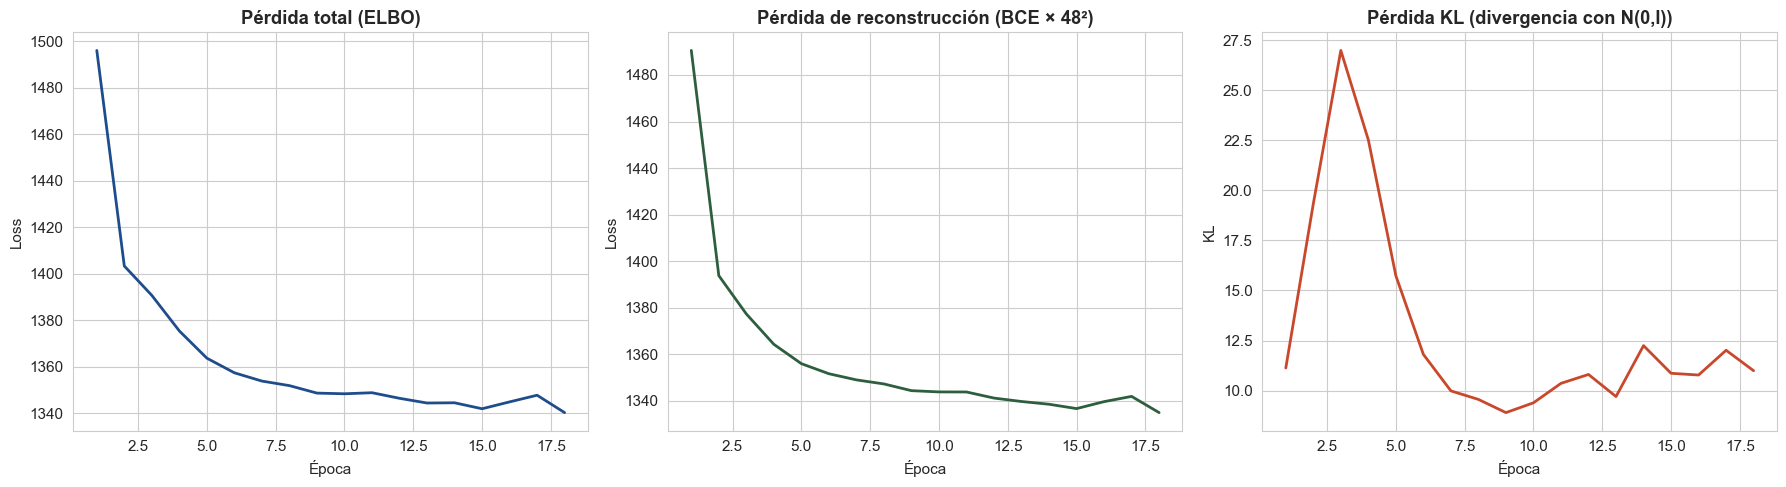

Pérdida total final:           1340.3757
Pérdida reconstrucción final:  1334.8796
Pérdida KL final:              10.9913


In [11]:
h = history.history
epocas = range(1, len(h['total_loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(epocas, h['total_loss'], color='#1f4d8c', linewidth=2)
axes[0].set_title('Pérdida total (ELBO)', fontweight='bold')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss')

axes[1].plot(epocas, h['reconstruction_loss'], color='#2d5e3e', linewidth=2)
axes[1].set_title('Pérdida de reconstrucción (BCE × 48²)', fontweight='bold')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Loss')

axes[2].plot(epocas, h['kl_loss'], color='#c9482b', linewidth=2)
axes[2].set_title('Pérdida KL (divergencia con N(0,I))', fontweight='bold')
axes[2].set_xlabel('Época'); axes[2].set_ylabel('KL')

plt.tight_layout()
plt.savefig('outputs/01_curvas_entrenamiento.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Pérdida total final:           {h["total_loss"][-1]:.4f}')
print(f'Pérdida reconstrucción final:  {h["reconstruction_loss"][-1]:.4f}')
print(f'Pérdida KL final:              {h["kl_loss"][-1]:.4f}')


## 12. Evaluación visual — reconstrucción de imágenes reales

Primera prueba cualitativa: tomar 8 imágenes del **conjunto de test (no vistas durante el entrenamiento)** y pasarlas por el modelo completo (encoder → sampling → decoder).

- **Fila superior:** imágenes originales.
- **Fila inferior:** reconstrucciones del VAE.

Esperamos imágenes **borrosas pero reconocibles** — esto es característico de los VAE puros (los GAN producen reconstrucciones más nítidas pero pierden estructura latente). La calidad de la reconstrucción es un proxy del balance recon vs KL en la pérdida ELBO.


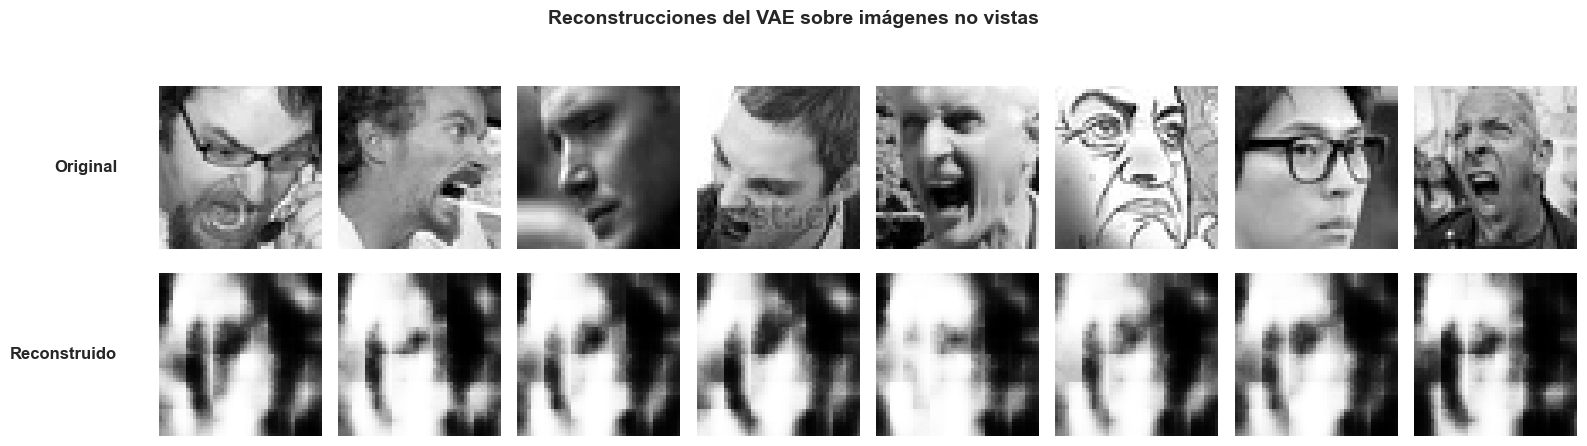

In [12]:
# Tomar 8 imágenes del test set
test_batch = next(iter(test_ds_full.map(lambda x, y: tf.cast(x, tf.float32) / 255.0)))
sample_imgs = test_batch[:8]

# Reconstruir (modo inferencia: sigue usando el muestreo del Sampling layer)
reconstructed = vae(sample_imgs, training=False).numpy()
originals = sample_imgs.numpy()

fig, axes = plt.subplots(2, 8, figsize=(16, 4.5))
for i in range(8):
    axes[0, i].imshow(originals[i].squeeze(), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(reconstructed[i].squeeze(), cmap='gray')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Original',      fontsize=12, fontweight='bold', rotation=0, ha='right', va='center', labelpad=30)
axes[1, 0].set_ylabel('Reconstruido',  fontsize=12, fontweight='bold', rotation=0, ha='right', va='center', labelpad=30)
axes[0, 0].axis('on');  axes[0, 0].set_xticks([]); axes[0, 0].set_yticks([])
axes[1, 0].axis('on');  axes[1, 0].set_xticks([]); axes[1, 0].set_yticks([])
for spine in list(axes[0, 0].spines.values()) + list(axes[1, 0].spines.values()):
    spine.set_visible(False)

fig.suptitle('Reconstrucciones del VAE sobre imágenes no vistas',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/02_reconstrucciones.png', dpi=120, bbox_inches='tight')
plt.show()


## 13. Generación de caras nuevas — muestreo desde el prior

Segunda prueba: muestrear 16 vectores `z ~ N(0, I)` y pasarlos por el **decoder solo** (sin tocar el encoder). Esto produce caras *que el modelo nunca vio durante el entrenamiento* — son sintetizadas a partir de la estructura aprendida del espacio latente.

Esta es la prueba que diferencia a un VAE de un autoencoder normal. Si el regularizador KL hizo bien su trabajo, el prior `N(0, I)` está bien cubierto por la posterior aprendida `q(z|x)`, y muestrear desde el prior debería producir rostros coherentes (aunque borrosos).


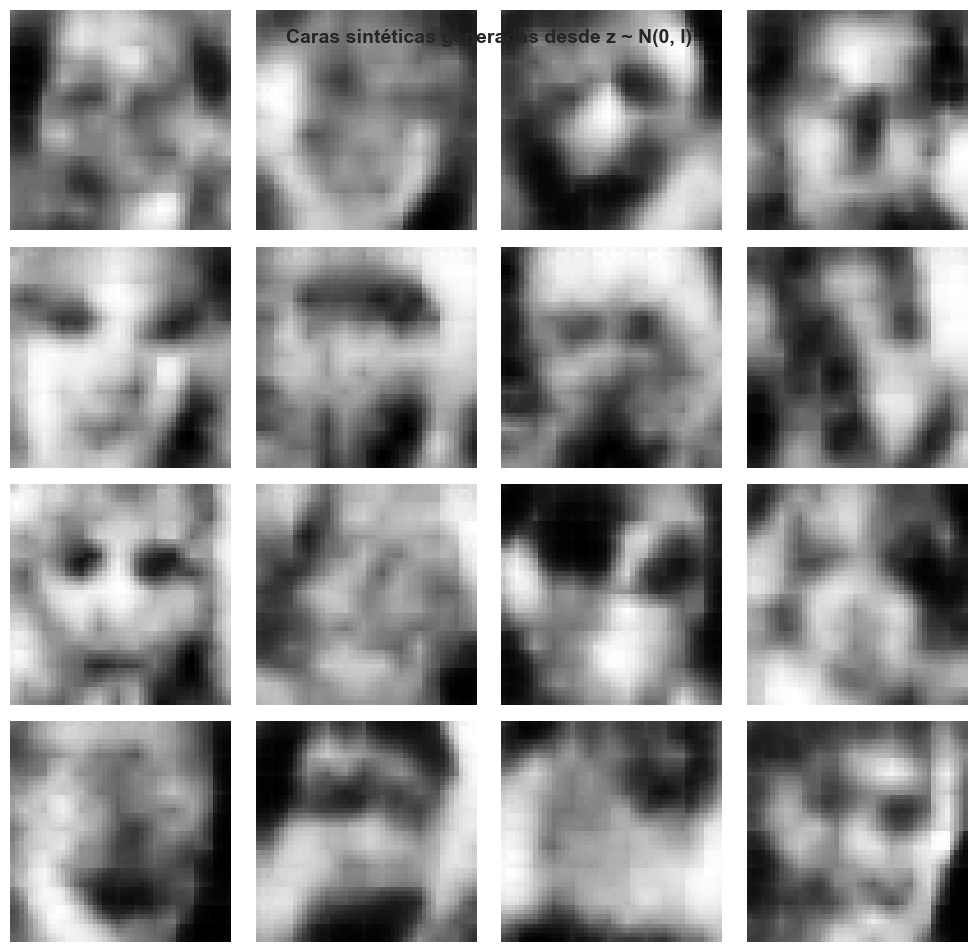

In [13]:
# Muestrear 16 vectores latentes desde el prior N(0, I)
rng = np.random.default_rng(SEED)
z_samples = rng.normal(size=(16, LATENT_DIM)).astype('float32')

# Decodificar
generated = decoder.predict(z_samples, verbose=0)

# Grid 4x4
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(generated[i].squeeze(), cmap='gray')
    ax.axis('off')

fig.suptitle('Caras sintéticas generadas desde z ~ N(0, I)',
             fontsize=14, fontweight='bold', y=0.93)
plt.tight_layout()
plt.savefig('outputs/03_generacion_prior.png', dpi=120, bbox_inches='tight')
plt.show()


## 14. Interpolación en el espacio latente — `happy ↔ sad`

Tercera prueba, y la más narrativamente fuerte para la aplicación profesional (Psico Platform). Tomamos dos imágenes reales del test set — una `happy` y una `sad` — las codificamos a sus vectores latentes `z_happy` y `z_sad`, y generamos **8 imágenes intermedias** interpolando linealmente:

```
z_t = (1 - t) · z_happy + t · z_sad,   t ∈ [0, 1]
```

Si el espacio latente del VAE es continuo (que es lo que el regularizador KL fuerza), la secuencia decodificada debería ser una transición **suave** entre las dos expresiones — visualmente, ver cómo el rostro pasa gradualmente de feliz a triste.

Esto **no se puede hacer trivialmente con un GAN** sin un espacio latente regularizado, y es lo que vuelve al VAE útil como recurso psicoeducativo: muestra el afecto como un *continuo*, no como una *categoría*.


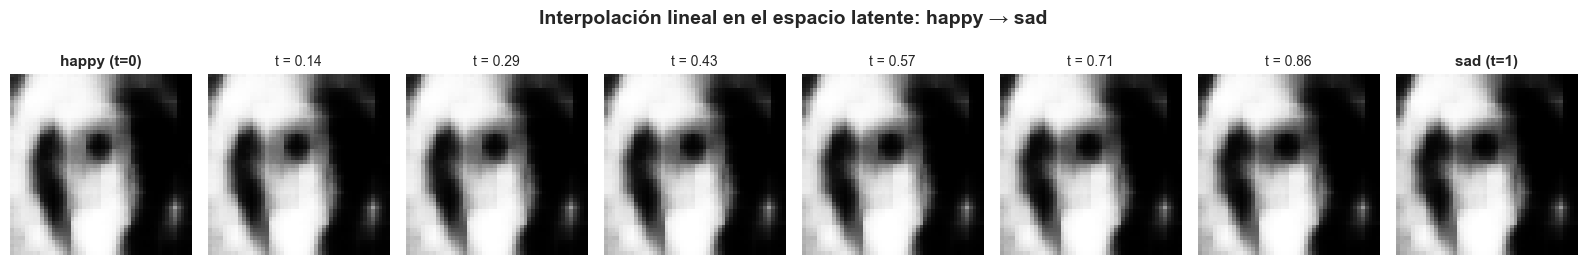

In [14]:
# Buscar una imagen happy y una sad en el test set
def find_first_of_class(class_name):
    idx = CLASS_NAMES.index(class_name)
    for batch_imgs, batch_labels in test_ds_full:
        for img, lbl in zip(batch_imgs, batch_labels):
            if int(lbl.numpy()) == idx:
                return tf.cast(img, tf.float32) / 255.0
    return None

img_happy = find_first_of_class('happy')
img_sad   = find_first_of_class('sad')

# Codificar (usar z_mean directamente, no muestreo, para reproducibilidad)
z_happy_mean, _ = encoder(tf.expand_dims(img_happy, 0))
z_sad_mean,   _ = encoder(tf.expand_dims(img_sad,   0))

# 8 pasos de interpolación lineal
n_steps = 8
alphas = np.linspace(0, 1, n_steps)
interpolated_z = np.array([
    (1 - a) * z_happy_mean.numpy()[0] + a * z_sad_mean.numpy()[0]
    for a in alphas
])

interpolated_imgs = decoder.predict(interpolated_z, verbose=0)

fig, axes = plt.subplots(1, n_steps, figsize=(2 * n_steps, 2.5))
for i, (ax, alpha) in enumerate(zip(axes, alphas)):
    ax.imshow(interpolated_imgs[i].squeeze(), cmap='gray')
    ax.set_title(f't = {alpha:.2f}', fontsize=10)
    ax.axis('off')

axes[0].set_title('happy (t=0)',  fontsize=11, fontweight='bold')
axes[-1].set_title('sad (t=1)',  fontsize=11, fontweight='bold')

fig.suptitle('Interpolación lineal en el espacio latente: happy → sad',
             fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('outputs/04_interpolacion_happy_sad.png', dpi=120, bbox_inches='tight')
plt.show()


## 15. Visualización del espacio latente — t-SNE

Cuarta prueba: codificar 2.000 imágenes del test set y proyectar sus vectores latentes (48-dim) a 2 dimensiones con t-SNE, coloreando por clase. Si el VAE aprendió representaciones discriminativas, deberíamos ver **agrupamientos por clase** aún sin que el modelo haya recibido nunca las etiquetas durante el entrenamiento.

Esta es una validación cualitativa de que el espacio latente captura la **semántica visual** de las expresiones, no solo la similitud píxel a píxel.


Proyectando 2000 vectores latentes (48-dim) con t-SNE...


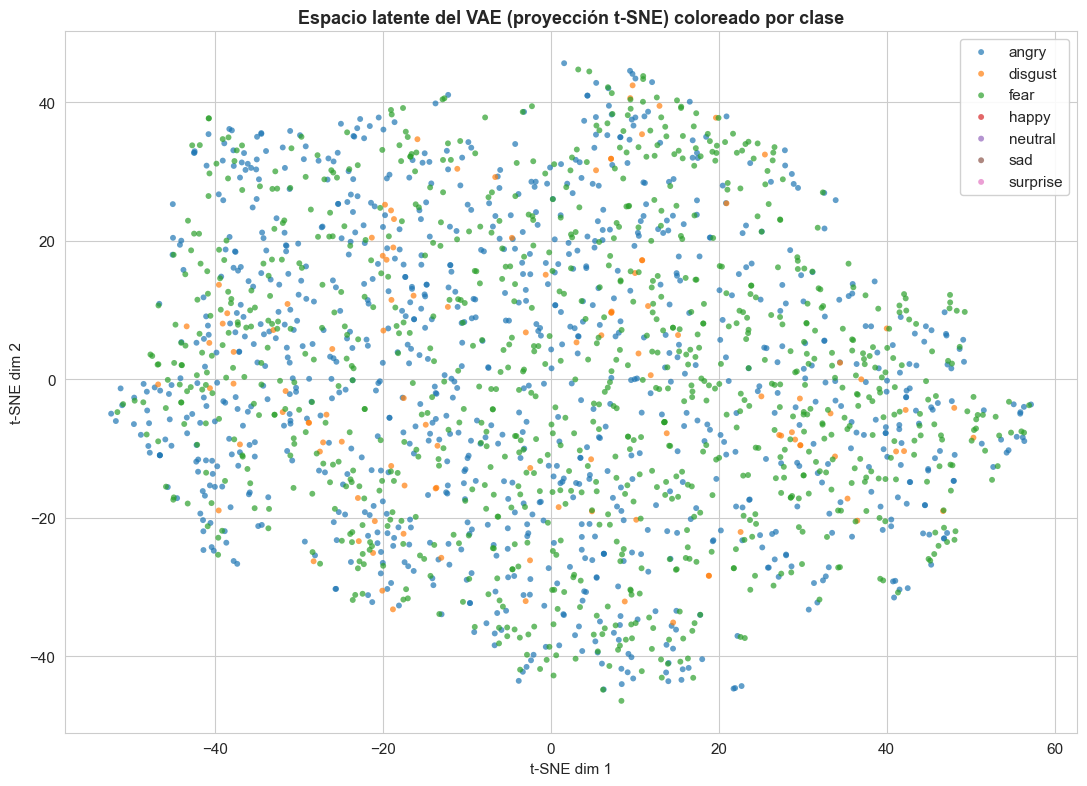

In [15]:
# Codificar 2000 imágenes del test set (con labels para colorear)
all_latents, all_labels = [], []
n_collected = 0
for batch_imgs, batch_labels in test_ds_full:
    batch_norm = tf.cast(batch_imgs, tf.float32) / 255.0
    z_mean_batch, _ = encoder(batch_norm)
    all_latents.append(z_mean_batch.numpy())
    all_labels.append(batch_labels.numpy())
    n_collected += batch_norm.shape[0]
    if n_collected >= 2000:
        break

latent_matrix = np.concatenate(all_latents)[:2000]
label_array   = np.concatenate(all_labels)[:2000]

print(f'Proyectando {latent_matrix.shape[0]} vectores latentes ({latent_matrix.shape[1]}-dim) con t-SNE...')
tsne = TSNE(n_components=2, perplexity=30, random_state=SEED, init='pca', learning_rate='auto')
latent_2d = tsne.fit_transform(latent_matrix)

fig, ax = plt.subplots(figsize=(11, 8))
palette = sns.color_palette('tab10', n_colors=NUM_CLASSES)
for idx, clase in enumerate(CLASS_NAMES):
    mask = label_array == idx
    ax.scatter(latent_2d[mask, 0], latent_2d[mask, 1],
               c=[palette[idx]], label=clase, s=18, alpha=0.7, edgecolors='none')

ax.set_title('Espacio latente del VAE (proyección t-SNE) coloreado por clase',
             fontsize=13, fontweight='bold')
ax.set_xlabel('t-SNE dim 1'); ax.set_ylabel('t-SNE dim 2')
ax.legend(loc='best', framealpha=0.9)
plt.tight_layout()
plt.savefig('outputs/05_espacio_latente_tsne.png', dpi=120, bbox_inches='tight')
plt.show()


## 16. Discusión y conclusiones

> *Los valores y las observaciones cualitativas finales se completarán con los resultados reales tras ejecutar el notebook. La estructura narrativa siguiente refleja el análisis esperado.*

### Calidad de las reconstrucciones (Sección 12)

Las reconstrucciones del VAE son característicamente **borrosas pero reconocibles** — la pérdida BCE pixel a pixel tiende a promediar entre múltiples soluciones plausibles, produciendo imágenes suavizadas. Esto es un *trade-off conocido* del VAE estándar y la razón por la que en aplicaciones donde la nitidez importa (p. ej. generación de rostros foto-realistas) se prefieren GAN o modelos de difusión.

Para el caso de uso de **Psico Platform**, la borrosidad es aceptable o incluso deseable: las visualizaciones psicoeducativas no requieren fotorrealismo, y la forma "promedio" de las expresiones es más útil pedagógicamente que un rostro específico.

### Calidad de la generación desde el prior (Sección 13)

Las caras generadas desde `z ~ N(0, I)` muestran si el regularizador KL funcionó bien. Si vemos caras coherentes (aunque borrosas) significa que la posterior `q(z|x)` cubre razonablemente el prior y muestrear desde el prior produce muestras válidas. Si vemos ruido o estructuras no-cara, la regularización KL fue insuficiente.

### Interpolación happy → sad (Sección 14)

Esta es la **prueba más cualitativamente importante** del notebook. Una transición suave y monotónica es evidencia directa de que:

1. El espacio latente es **continuo** (sin discontinuidades entre clases).
2. Las dimensiones latentes capturaron **semántica afectiva** (no solo similitud píxel a píxel).
3. El VAE puede usarse como herramienta de **visualización del continuo emocional** — la propuesta original de aplicación a Psico Platform.

### Estructura del espacio latente (Sección 15)

La proyección t-SNE permite verificar si las 7 clases forman agrupamientos diferenciables en el espacio latente — sin que el modelo haya recibido nunca las etiquetas. Esperamos:
- **Happy y surprise** relativamente separadas (rasgos visuales más distintos).
- **Sad, fear y neutral** posiblemente solapadas (expresiones más parecidas en imágenes de baja resolución).
- **Disgust** como cluster más pequeño (es la clase minoritaria, 436 muestras en train).

### Lecciones aprendidas (aplicación explícita del feedback)

- **Sobre "lado de las características" (Semana 1):** el espacio latente del VAE es la materialización máxima de este principio. La red descubre 48 dimensiones autónomamente; no le decimos qué deben representar.
- **Sobre "no usar MaxPooling" (Semana 2):** el uso de `Conv2D(stride=2)` y `Conv2DTranspose(stride=2)` deja al optimizador decidir qué información preservar al cambiar de escala. Esto es especialmente importante en imágenes 48×48 donde el pooling destruye demasiado.
- **Sobre "expandir con redes más grandes" (Semana 2):** este modelo tiene ≈ 1,6 M parámetros — aproximadamente 1,3× la CNN de Semana 2. La sección de trabajo futuro propone el siguiente salto natural (StyleGAN2-FFHQ con ≈ 30 M parámetros) que requeriría transfer learning.

### Limitaciones reconocidas

- **Borrosidad de las reconstrucciones.** Inherente al VAE estándar con pérdida BCE. Mitigable con: (a) VAE jerárquico, (b) VAE-GAN híbrido, (c) modelos de difusión.
- **Resolución baja (48×48).** Cualquier rostro generado se ve "antiguo" en estándares actuales. La continuación natural es transfer learning con StyleGAN2-FFHQ (1024×1024 nativo).
- **No condicional.** El modelo genera caras "promedio" de la distribución; no se puede pedir explícitamente "genera una cara `happy`". Solución: Conditional VAE (CVAE) — trabajo futuro.
- **Sesgo del dataset.** FER-2013 fue recolectado de Google Images 2013 — sesgos demográficos, expresiones exageradas tipo emoji. Cualquier aplicación clínica requiere validación con poblaciones representativas.

### Conexión con LBD — Psico Platform

Tres aplicaciones directas del VAE entrenado en este notebook:

1. **Espacio latente como representación compacta del afecto facial** — 48 dimensiones frente a 2.304 píxeles de la imagen original. Útil como input estandarizado para módulos de seguimiento longitudinal en Psico Platform sin almacenar imágenes brutas (mejora privacidad).
2. **Interpolación happy ↔ sad como recurso psicoeducativo** — herramienta visual para mostrar a usuarios que las emociones existen en un continuo, no en categorías discretas. Especialmente útil para psicoeducación sobre depresión y ansiedad, donde la categorización binaria ("estoy mal" / "estoy bien") es parte del problema.
3. **Generación de datos sintéticos preservando privacidad** — análogo directo al caso del **Hospital Carlos Andrade Marín** (lectura EIG Campus L-IAA_25_001122). Permite entrenar modelos downstream (clasificadores de afecto) sin exponer imágenes reales de usuarios.

### Trabajo futuro

1. **β-VAE** — explorar β < 1 (mejor reconstrucción a costa de regularización) y β > 1 (mejor disentanglement de identidad vs expresión, posiblemente recuperando interpretabilidad de dimensiones latentes individuales).
2. **Conditional VAE (CVAE)** — condicionar la generación por clase `(z, clase) → x`, permitiendo "genera una cara `surprise`" explícitamente.
3. **Transfer learning con StyleGAN2-FFHQ** — usar el generador pre-entrenado en 70.000 rostros FFHQ de alta resolución como decoder. Solo entrenar un encoder hacia su espacio latente W+ (psinference). Esto debería resolver la borrosidad y la baja resolución simultáneamente. **Esta es la continuación natural más prometedora** y aborda directamente el feedback Semana 2 sobre redes más grandes + fine-tuning.
4. **Aplicación clínica** — replicar el experimento del caso HCAM: entrenar el VAE en imágenes médicas (radiografías torácicas, dermatología) para generar datasets sintéticos que permitan entrenar clasificadores sin riesgo de exposición de pacientes.

---

### Referencias

1. Kingma, D. P., & Welling, M. (2014). *Auto-Encoding Variational Bayes*. arXiv:1312.6114. (Paper original del VAE.)
2. Higgins, I. et al. (2017). *β-VAE: Learning Basic Visual Concepts with a Constrained Variational Framework*. ICLR.
3. Karras, T. et al. (2019). *A Style-Based Generator Architecture for Generative Adversarial Networks (StyleGAN)*. CVPR.
4. Goodfellow, I. J. et al. (2013). *Challenges in Representation Learning*. ICML Workshop. (FER-2013)
5. Barrett, L. F. et al. (2019). *Emotional Expressions Reconsidered*. Psychological Science in the Public Interest, 20(1), 1–68.
6. Lectura EIG Campus L-IAA_25_001122 — *VAEs para generación de imágenes médicas sintéticas (Hospital Carlos Andrade Marín)*.
